# Telco Customer Churn: Data Cleaning Preprocessing
## Machine Learning Midterm Project
### Project Objective
The objective of this project is to explore, clean, and preprocess the Telco Customer Churn dataset so that it can be used for machine-learning classification. The future model will predict weather a telecommunications customer is likely to cancel the company's service.

### Data Source
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Target Variable
The target variable is 'Churn', which indicates weather a customer canceled the service.

In [1]:
### Import libraries for data analysis
import pandas as pd
import numpy as np

### Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Display all DataFrame columns
pd.set_option("display.max_columns", None)

### Apply a clean chart style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load and verify the original Dataset
The original Telco Customer Churn dataset is loaded from the `data` folder. A separate working copy is created so the original dataset remains unchanged.

In [2]:
from pathlib import Path

# Define the exact location of the approved dataset
data_path = Path("data") / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Stop with a clear messege if the file is not found
if not data_path.exists():
    raise FileNotFoundError(
        f"Data not found at {data_path.resolve()}")

# Load the original dataset
df_original = pd.read_csv(data_path)

# Create a working copy for analysis and preprocessing 
df = df_original.copy()

# Verify that the approved dataset loaded correctly
print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

assert df.shape == (7043, 21), (
    f"Unexpected dataset shape: {df.shape}. "
    "Expected 7,043 rows and 21 columns.")

print("Dataset dimensions verified successfully.")

Dataset loaded successfully.
Number of rows: 7043
Number of columns: 21
Dataset dimensions verified successfully.


# 2. Initial Dataset Inspection
Before cleaning or preprocessing the dataset, the first five records are displayed to understand its structure, variables, and values.

In [3]:
# Display the first five rows of the working dataset
first_five_rows = df.head()
display(first_five_rows)

# Verify the size of the displayed preview
print("Preview rows:", first_five_rows.shape[0])
print("Preview columns:", first_five_rows.shape[1])

assert first_five_rows.shape == (5, 21), (
    f"Unexpected preview shape: {first_five_rows.shape}")

print("First five records displayed successfully.")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Preview rows: 5
Preview columns: 21
First five records displayed successfully.


# 3. Split the dataset
The original dataset is divided into 70% training data and 30% testing data. Stratification preserves the original proportion of the 'Churn' classes in both datasets.

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["Churn"])

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

print("\nTraining target counts:")
print(train_df["Churn"].value_counts())

print("\nTesting target counts:")
print(test_df["Churn"].value_counts())

Training data shape: (4930, 21)
Testing data shape: (2113, 21)

Training target counts:
Churn
No     3622
Yes    1308
Name: count, dtype: int64

Testing target counts:
Churn
No     1552
Yes     561
Name: count, dtype: int64


# 4. Training data quality check
Only the training data is examined for data types, missing values, blank values, and duplicate rows. The testing data remains untouched.


In [5]:
# Display the data type of each training column
print("Column data types:")
print(train_df.dtypes)

# Count standard null values
total_nulls = train_df.isna().sum().sum()

# Count blank strings in text columns
text_columns = train_df.select_dtypes(include="object").columns
blank_counts = train_df[text_columns].apply(
    lambda column: column.astype(str).str.strip().eq("").sum())
blank_counts = blank_counts[blank_counts > 0]

# Count duplicaterows
duplicate_rows = train_df.duplicated().sum()

print("\nTotal null value:", total_nulls)
print("\nColumns containing blank values:")
print(blank_counts)
print("\nDuplicate rows:", duplicate_rows)

Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Total null value: 0

Columns containing blank values:
TotalCharges    7
dtype: int64

Duplicate rows: 0


# 5. Exploratory Data Analysis
The churn distribution is examined using only training dataset

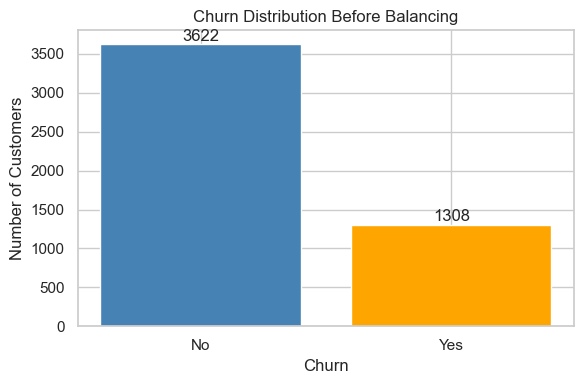

Churn
No     3622
Yes    1308
Name: count, dtype: int64


In [6]:
# Churn distribution in the training data only
churn_counts = train_df["Churn"].value_counts().reindex(["No", "Yes"])

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values, color=["steelblue", "orange"])

plt.title("Churn Distribution Before Balancing")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for index, value in enumerate(churn_counts.values):
    plt.text(index, value + 40, str(value), ha="center")

plt.tight_layout()
plt.show()

print(churn_counts)

# 6. Data Cleaning
'TotalCharges' was stored as text because it contained blank values. The blank records belong to new customers with zero months of tenure, so they are replaced with 0 before converting the column to numeric.

In [7]:
# Create a cleaned copy of the training data
train_clean = train_df.copy()

# Identify blank TotalCharges record
blank_mask = train_clean["TotalCharges"].astype(str).str.strip().eq("")

# Verify that every blank record belongs to a new customer
assert train_clean.loc[blank_mask, "tenure"].eq(0).all(), (
    "Some blank TotalCharges records have nonzero tenure.")

# Convert TotalCharges to numeric and replace verified blanks with 0
train_clean["TotalCharges"] = pd.to_numeric(
    train_clean["TotalCharges"], errors="coerce")
train_clean["TotalCharges"] = train_clean["TotalCharges"].fillna(0)

print("Blank value handled:", blank_mask.sum())
print("Remaining missing TotalCharges:", train_clean["TotalCharges"].isna().sum())
print("TotalCharges data type:", train_clean["TotalCharges"].dtype)

Blank value handled: 7
Remaining missing TotalCharges: 0
TotalCharges data type: float64


# Numeric Feature Distributions Before Scaling
The numerical features are visualized before scaling to understand their original ranges and distributions.

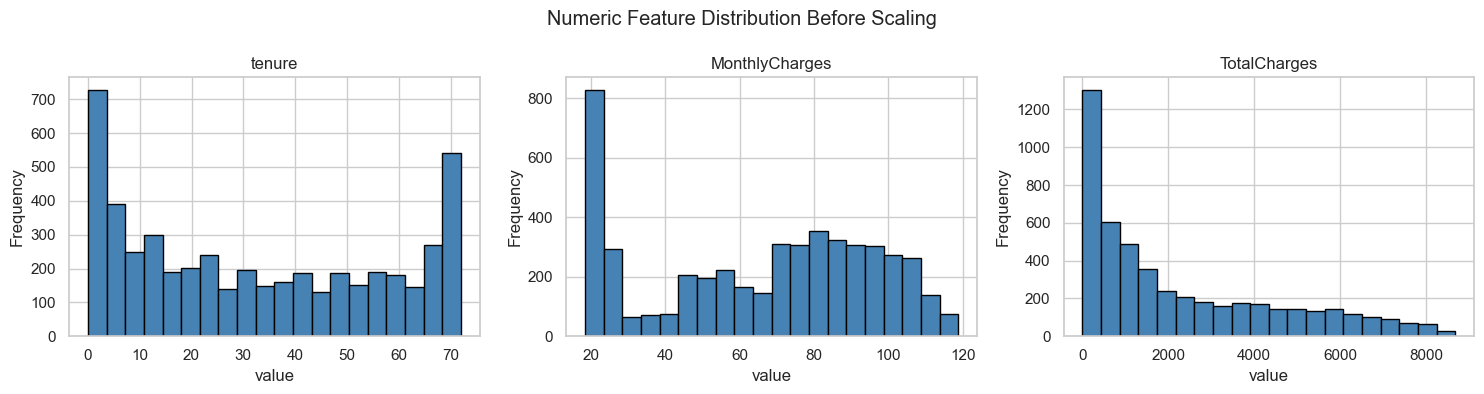

In [8]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, column in zip(axes, numeric_columns):
    axis.hist(
        train_clean[column],
        bins=20,
        color="steelblue",
        edgecolor="black")

    axis.set_title(column)
    axis.set_xlabel("value")
    axis.set_ylabel("Frequency")

plt.suptitle("Numeric Feature Distribution Before Scaling")
plt.tight_layout()
plt.show()

# 7. Feature Engineering
A new feature named `TotalServices' is created to represent the number of telecommunications services used by each customer. The customer ID is excluded because it is only an identifier, and the target is encoded as 0 for No and 1 for Yes.

In [9]:
# Columns that representindividual customer services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"]

# Count active sevices and include internet service
train_clean["TotalServices"] = (
    train_clean[service_columns].eq("Yes").sum(axis=1)
    + train_clean["InternetService"].ne("No").astype(int))

# Separate features and target
x_train = train_clean.drop(columns=["customerID", "Churn"])
y_train = train_clean["Churn"].map({"No": 0, "Yes": 1})

# Verify the results
assert y_train.notna().all(), "Unexpected value found in the Churn column."
assert train_clean["TotalServices"].between(0, 9).all()

print("Training features shape:", x_train.shape)
print("Training target shape:", y_train.shape)
print("\nEncoded target counts:")
print(y_train.value_counts().sort_index())
print("\nTotalServices sample:")
print(train_clean[["TotalServices"]].head())


Training features shape: (4930, 20)
Training target shape: (4930,)

Encoded target counts:
Churn
0    3622
1    1308
Name: count, dtype: int64

TotalServices sample:
      TotalServices
5557              3
2270              4
6930              3
2257              7
898               6


# 8. Encoding, Normalization, and Scaling
Numerical features are normalized and scaled, while categorical features are converted into numerical columns using one-hot encoding. All transformations are fitted only on the training data to prevent data leakage.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, MinMaxScaler

# Define the feature groups
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices"]

categorical_columns = x_train.select_dtypes(include="object").columns.tolist()

# Normalize the distributions and scale values between 0 and 1
numeric_processor = Pipeline([
    ("normalization", PowerTransformer(method="yeo-johnson")),
    ("scaling", MinMaxScaler())])

# Convert categorical features into numerical columns
categorical_processor = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False)

# Combine the preprocessing operation
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_processor, numeric_columns),
        ("categorical", categorical_processor, categorical_columns)],
    remainder="passthrough")

# Fit and transform only the training features
x_train_processed_array = preprocessor.fit_transform(x_train)

# Obtain the processed column names
processed_feature_names = preprocessor.get_feature_names_out()

# Convert the result into a DataFrame
x_train_processed = pd.DataFrame(
    x_train_processed_array,
    columns=processed_feature_names,
    index=x_train.index)

assert x_train_processed.isna().sum().sum() == 0

print("Original training shape:", x_train.shape)
print("Processed training shape:", x_train_processed.shape)
print("Missing value after preprocessing :",
      x_train_processed.isna().sum().sum())

display(x_train_processed.head())

Original training shape: (4930, 20)
Processed training shape: (4930, 46)
Missing value after preprocessing : 0


,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,numeric__TotalServices,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No,categorical__OnlineBackup_No internet service,categorical__OnlineBackup_Yes,categorical__DeviceProtection_No,categorical__DeviceProtection_No internet service,categorical__DeviceProtection_Yes,categorical__TechSupport_No,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__StreamingTV_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__StreamingMovies_No,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,remainder__SeniorCitizen
5557,0.212370,0.629611,0.393681,0.336023,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2270,0.148581,0.694326,0.327835,0.471139,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
6930,0.148581,0.580195,0.325714,0.336023,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2257,0.909897,0.633027,0.847534,0.809581,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
898,0.371000,0.810656,0.550684,0.705294,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


# 9. Class Balancing
The training dataset is imbalanced because fewer customers have churned. Random oversampling is applied only to the processed training data. The testing data is not used or balanced.

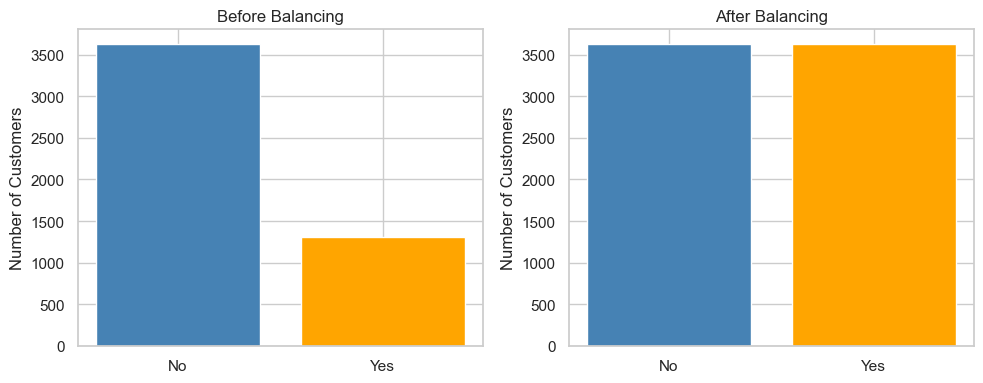

Before balancing:
Churn
0    3622
1    1308
Name: count, dtype: int64

After balancing:
Churn
0    3622
1    3622
Name: count, dtype: int64

Balanced training shape: (7244, 46)


In [11]:
from sklearn.utils import resample

# Combine the processed features and target temporarily
processed_train = x_train_processed.copy()
processed_train["Churn"] = y_train

# Separate the majority and minority classes
majority_class = processed_train[processed_train["Churn"] == 0]
minority_class = processed_train[processed_train["Churn"] == 1]

# Increase the minority class to match the majority class
minority_upsampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42)

# Combine and shuffle the balanced training data
balanced_train = pd.concat(
    [majority_class, minority_upsampled],
    axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Separate the balanced features and target
x_train_balanced = balanced_train.drop(columns="Churn")
y_train_balanced = balanced_train["Churn"].astype(int)

# Compare class counts before and after balancing
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_balanced.value_counts().sort_index()

figm, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["No", "Yes"], before_counts.values,
            color=["steelblue", "orange"])
axes[0].set_title("Before Balancing")
axes[0].set_ylabel("Number of Customers")

axes[1].bar(["No", "Yes"], after_counts.values,
            color=["steelblue", "orange"])
axes[1].set_title("After Balancing")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print("Before balancing:")
print(before_counts)

print("\nAfter balancing:")
print(after_counts)

print("\nBalanced training shape:", x_train_balanced.shape)




# 10. Test Data Processing and Export
The same cleaning and feature-engineering rules are applied to the testing data. The preprocessing transformer fitted on the training data is used only to transform the testing data. The testing data is not used for fitting or class balancing.

In [12]:
# Create a copy of the untouched testing data
test_clean = test_df.copy()

# Convert TotalCharges to numeric
test_clean["TotalCharges"] = pd.to_numeric(
    test_clean["TotalCharges"],
    errors="coerce"
)

# Verify that missing TotalCharges records have zero tenure
missing_test_charges = test_clean["TotalCharges"].isna()

assert test_clean.loc[missing_test_charges, "tenure"].eq(0).all(), (
    "Some missing TotalCharges records have nonzero tenure."
)

# Apply the same cleaning rule used for the training data
test_clean["TotalCharges"] = test_clean["TotalCharges"].fillna(0)

# Apply the same feature engineering
test_clean["TotalServices"] = (
    test_clean[service_columns].eq("Yes").sum(axis=1)
    + test_clean["InternetService"].ne("No").astype(int)
)

# Separate testing features and target
x_test = test_clean.drop(columns=["customerID", "Churn"])
y_test = test_clean["Churn"].map({"No": 0, "Yes": 1})

# Verify that training and testing features match
assert list(x_test.columns) == list(x_train.columns)
assert y_test.notna().all()

# Transform using the preprocessing fitted on training data
x_test_processed_array = preprocessor.transform(x_test)

x_test_processed = pd.DataFrame(
    x_test_processed_array,
    columns=processed_feature_names,
    index=x_test.index
)

# Final verification
assert x_test_processed.isna().sum().sum() == 0
assert list(x_train_balanced.columns) == list(x_test_processed.columns)

# Prepare final export datasets
final_training_data = x_train_balanced.copy()
final_training_data["Churn"] = y_train_balanced.values

final_testing_data = x_test_processed.copy()
final_testing_data["Churn"] = y_test

# Create the output folder and save both datasets
output_folder = Path("output")
output_folder.mkdir(exist_ok=True)

training_file = output_folder / "telco_churn_processed_training.csv"
testing_file = output_folder / "telco_churn_processed_testing.csv"

final_training_data.to_csv(training_file, index=False)
final_testing_data.to_csv(testing_file, index=False)

print("Final training shape:", final_training_data.shape)
print("Final testing shape:", final_testing_data.shape)
print("Training missing values:", final_training_data.isna().sum().sum())
print("Testing missing values:", final_testing_data.isna().sum().sum())
print("\nSaved training file:", training_file)
print("Saved testing file:", testing_file)

display(final_training_data.head())

Final training shape: (7244, 47)
Final testing shape: (2113, 47)
Training missing values: 0
Testing missing values: 0

Saved training file: output\telco_churn_processed_training.csv
Saved testing file: output\telco_churn_processed_testing.csv


,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,numeric__TotalServices,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No,categorical__OnlineBackup_No internet service,categorical__OnlineBackup_Yes,categorical__DeviceProtection_No,categorical__DeviceProtection_No internet service,categorical__DeviceProtection_Yes,categorical__TechSupport_No,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__StreamingTV_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__StreamingMovies_No,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,remainder__SeniorCitizen,Churn
0,0.109810,0.625217,0.296359,0.336023,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
1,0.704183,0.532991,0.703943,0.182464,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
2,0.239801,0.309127,0.365100,0.471139,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
3,0.471216,0.074268,0.415613,0.182464,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,0.963540,0.624729,0.869147,0.809581,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1


# 11. Machine Learning Application and Conclusion

The processed dataset can be used to build a supervised classification model that predicts whether a telecommunications customer will churn. The target variable is 'Churn', where 0 represents No and 1 represents Yes.

The data was split into 70% training and 30% testing before analysis. Missing values were handled, categorical variables were one-hot encoded, numerical features were normalized and scaled, a 'TotalServices' feature was created, and the training classes were balanced. The testing data was transformed using the preprocessing fitted only on the training data.

Possible classification models include logistic regression, decision trees, random forests, and support vector machines. Model performance could be evaluated using accuracy, precision, recall, F1-score, and the confusion matrix. Recall would be especially important because the goal is to identify customers who may leave so the company can take retention action.